## Kelley hu4d5-5 VL-Y92A error analysis

In this notebook we will use a random forest model to find the most energetically influential degrees of freedom for the VL-Y92A TI production run. Next, we will compare the sampling of these DOF during TI production to a free energy profile derived from end state GaMD sampling. We will attempt to correct any inaccurate sampling in the TI data and find the estimated ddG before and after the correction. 

In [1]:
import os
os.chdir("..")
from common_functions import *

### Ingesting original TI lambda production data 

Reading in each TI lambda production frame, its DV/DL, and the side chain rotamers or key interatomic distances involving any residues within 5 A of the softcore region. Check the methods section of the manuscript if you are interested in the detailed method used to find these nearby geometric degrees of freedom.

In [2]:
os.chdir("./TI_data/VL-Y92A/")
geom_dvdls = pd.read_csv("Y92A_bound.csv")
geom_dvdls_ub = pd.read_csv("Y92A_unbound.csv")

### Computing original TI ddG estimate

In [3]:
orig_dGs = np.array(bootstrap_df(geom_dvdls, 1000, 200))
orig_ub_dGs = np.array(bootstrap_df(geom_dvdls_ub, 1000, 200))

In [4]:
print("Original estimates: ")
orig_ddGs = print_summary(orig_dGs, orig_ub_dGs)

print()
empirical_value = 1.36
orig_error = abs(np.mean(orig_ddGs) - empirical_value)
print(f"Original ddG error: {round(orig_error, 4)} kcal/mol")

Original estimates: 
Total ddG: 1.3516 +/- 0.6601
Lower CI: 0.6915
Upper CI: 2.0016

Original ddG error: 0.0084 kcal/mol


### Formatting TI side chain rotamers and dV/dLs as input data for random forest model

In [5]:
X = geom_dvdls.drop([
    "#Frame", "weight_dvdl", "dvdl", "Run", "Lambda", "H446_chi2", "Q445_chi3", "k82_y227", "T448_chi1"
], axis=1)

Y = geom_dvdls["weight_dvdl"]

X_scl = pd.DataFrame(StandardScaler().fit_transform(X))
X_scl.columns = X.columns


### Removing cross-correlated variables in independent variable set

Eventually, the cleaned set of nearby side chain rotamers will be plugged into a model with the weighted dV/dL values as the target variable and we will find out which of the side chain rotamers has the biggest impact on TI dV/dL.

In [6]:
absCorr = abs(X_scl.corr())
for i in absCorr.columns:
    for j in absCorr.index:
        cor = absCorr.loc[i, j]
        if abs(cor) > 0.5 and i != j:
            print(i, j)
            print(cor)
            

#### Random forest model to find most influential side chain rotamers on dV/dL

In [7]:
rfeDefault = RFE(estimator=DecisionTreeRegressor(max_depth=5, random_state=42), n_features_to_select=0.75, step=0.05)
rfDefault = RandomForestRegressor(
    max_depth=10, n_estimators=200, oob_score=True, max_features=0.6, min_samples_leaf = 7, min_samples_split=14, random_state=42,
    n_jobs=-1
)

pipelineDefault_rf = Pipeline([
    ('feature_scaling', StandardScaler()),
    ('feature_selection', rfeDefault),
    ('regression_model', rfDefault)
])


imps = benchmark_model(pipelineDefault_rf, X_scl, Y, geom_dvdls["Lambda"])
imps[["Mean", "Median"]].sort_values(by="Mean", ascending=False)[:15]

Avg. training r2: 
0.7388
Training r2 std dev: 
0.0004
Avg. test r2: 
0.6431
Testing r2 std dev: 
0.0065


,Mean,Median
Y447_chi1,0.409392,0.440812
e111_y227,0.177719,0.178047
Y447_chi2,0.077771,0.046115
V384_chi1,0.065337,0.075875
D383_chi1,0.049577,0.059666
H446_chi1,0.038995,0.041319
I357_chi2,0.029931,0.032879
T452_chi1,0.021352,0.021357
N385_chi1,0.019485,0.011235
D383_chi2,0.018866,0.009528


### Comparing sampling during TI with 1-D GaMD pmf of VL-Y92 chi1 (bound state)

The RF model found the most influential feature to be VL-Y92 chi1. When we examine the GaMD free energy profile, we see one predominant microstate, which is fairly well-sampled during TI. We also see significant sampling outside of this microstate during TI.

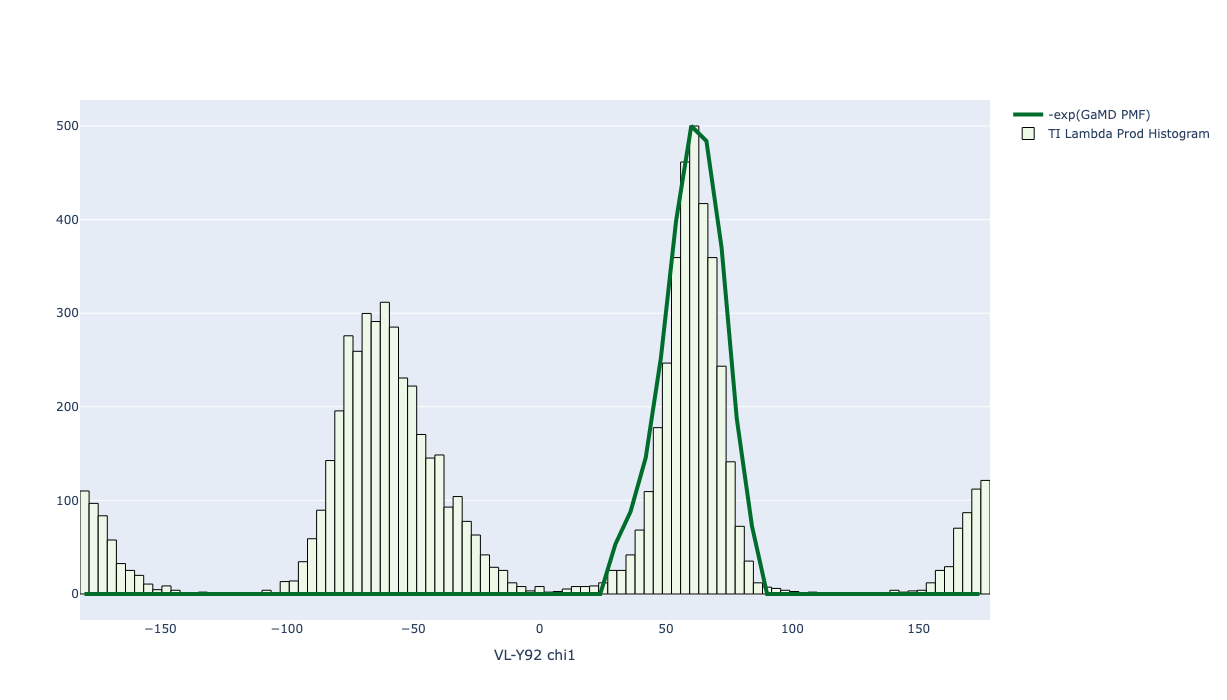

In [8]:
os.chdir("../../gamd_pmfs/VL-Y92A")
y227c1 = get_pmf("pmf-c2-Y92_chi1_bound.dat.xvg")

fig = plot_pmf_TI_1D_fig(
    y227c1, geom_dvdls, "Y447_chi1", 500, 100
).update_xaxes(
    title="VL-Y92 chi1"
).update_layout(
    width=1000,
    height=700
)
fig.show(
    renderer="jupyterlab"
)

In [9]:
st1 = geom_dvdls[(geom_dvdls["Y447_chi1"] > 24) & (geom_dvdls["Y447_chi1"] < 90)]
print(st1.groupby("Lambda").count()["weight_dvdl"])

Lambda
1     637
2     577
3     790
4     740
5     597
6     656
7     513
8     233
9      75
10     32
11     77
12     63
Name: weight_dvdl, dtype: int64


#### Ingesting more TI sampling to increase sample size at lambdas 9-12

When we filter to only the predominant microstate we see a drastic reduction in sample size for lambdas 9-12 (see print output above). Therefore, we executed additional TI simulations to get more robust sampling at this microstate for lambdas 9-12.

In [10]:
os.chdir("../../TI_data/VL-Y92A")
geom_dvdls_boosted = pd.read_csv("Y92A_bound_boosted.csv")

st1_boosted = geom_dvdls_boosted[
    (geom_dvdls_boosted["Y447_chi1"] > 24) & 
    (geom_dvdls_boosted["Y447_chi1"] < 90) 
]
print(st1_boosted.groupby("Lambda").count()["weight_dvdl"])

Lambda
1     1699
2     2278
3     1258
4      895
5      686
6      663
7     2864
8     1581
9      272
10     249
11     321
12     249
Name: weight_dvdl, dtype: int64


#### Bootstrap sampling from predominant microstate to generate corrected bound state dG

In [11]:
bound_corr_dGs = np.array(bootstrap_df(st1_boosted, 1000, 200))

### Comparing sampling during TI with 1-D GaMD pmf of VL-Y92 chi1 (unbound state)

In the unbound state, the VL-Y92 chi rotamer is a bit more flexible, revealing two predominant microstates. The leftmost one mirrors the one in the bound state, and then a smaller microstate on the right also appears.

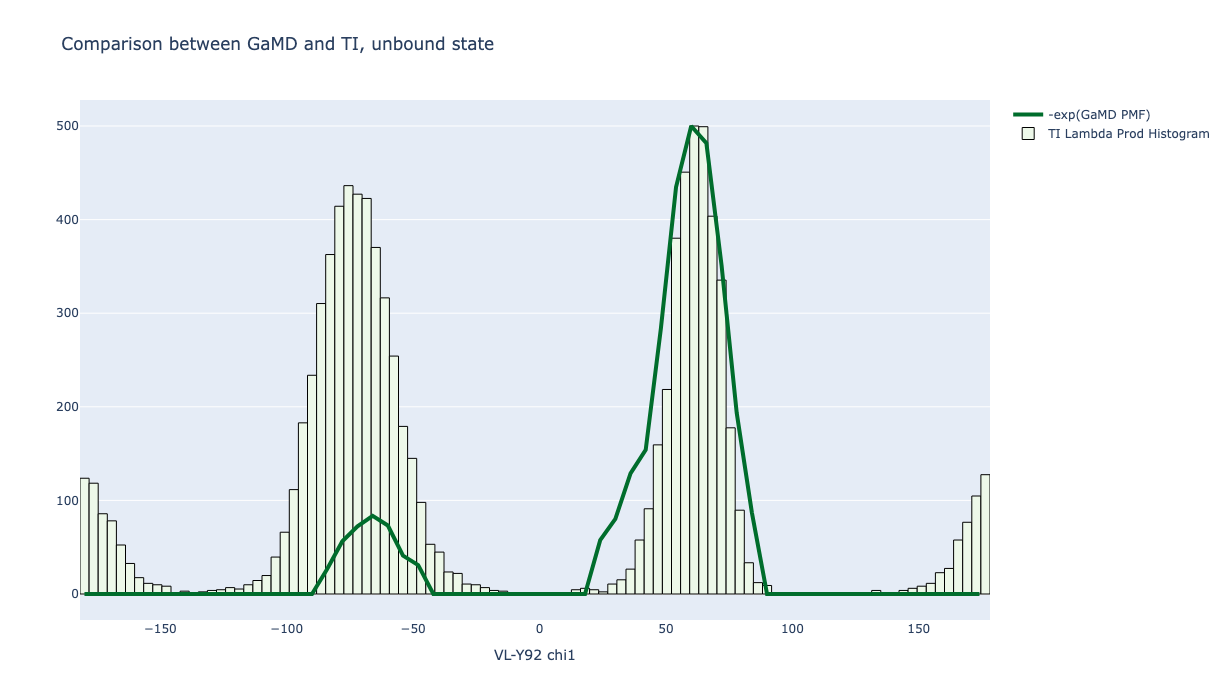

In [12]:
os.chdir("../../gamd_pmfs/VL-Y92A")
y92c1_ub = get_pmf("pmf-c2-Y92_chi1_unbound.dat.xvg")

fig = plot_pmf_TI_1D_fig(
    y92c1_ub, geom_dvdls_ub, "Y312_chi1", 500, 100
).update_xaxes(
    title="VL-Y92 chi1"
).update_layout(
    width=1000,
    height=700,
    title="Comparison between GaMD and TI, unbound state"
)
fig.show(
    renderer="jupyterlab"
)

a1ub = y92c1_ub[y92c1_ub["X"] < 0]["pop"].sum()
a2ub = y92c1_ub[y92c1_ub["X"] > 0]["pop"].sum()

a1ub_prop = a1ub/(a1ub + a2ub)
a2ub_prop = a2ub/(a1ub + a2ub)

In [13]:
st1_ub = geom_dvdls_ub[(geom_dvdls_ub["Y312_chi1"] > -90) & (geom_dvdls_ub["Y312_chi1"] < -42)]
st2_ub = geom_dvdls_ub[(geom_dvdls_ub["Y312_chi1"] > 18) & (geom_dvdls_ub["Y312_chi1"] < 90)]

print(st1_ub.groupby("Lambda").count()["weight_dvdl"])
print(st2_ub.groupby("Lambda").count()["weight_dvdl"])

Lambda
1     172
2      26
3     162
4     218
5     216
6     218
7     581
8     775
9     845
10    841
11    647
12    556
Name: weight_dvdl, dtype: int64
Lambda
1     798
2     803
3     791
4     598
5     601
6     596
7     317
8       2
9      19
10      3
11     24
12     26
Name: weight_dvdl, dtype: int64


#### Ingesting more TI sampling to fill in gaps 

Above, when we filter to the two microstates we see a drastic reduction in sample size for lambdas 9-12 in the leftmost microstate just like in the bound state. On the right-hand side, there is insufficient sampling at lambda=2.

In [14]:
os.chdir("../../TI_data/VL-Y92A")
geom_dvdls_ub_boost = pd.read_csv("Y92A_unbound_boosted.csv")

st1_ub_boost = geom_dvdls_ub_boost[
    (geom_dvdls_ub_boost["Y312_chi1"] > -90) & 
    (geom_dvdls_ub_boost["Y312_chi1"] < -42) 
]

st2_ub_boost = geom_dvdls_ub_boost[
    (geom_dvdls_ub_boost["Y312_chi1"] > 18) & 
    (geom_dvdls_ub_boost["Y312_chi1"] < 90) 
]

print(st1_ub_boost.groupby("Lambda").count()["weight_dvdl"])
print(st2_ub_boost.groupby("Lambda").count()["weight_dvdl"])

Lambda
1     1036
2     1164
3     2364
4     2270
5     2070
6     3819
7     2888
8     2430
9     3732
10    5760
11    4616
12    4162
Name: weight_dvdl, dtype: int64
Lambda
1     7176
2     7347
3     5950
4     5526
5     5292
6     4148
7     1579
8      422
9      501
10     422
11     408
12     432
Name: weight_dvdl, dtype: int64


In [15]:
st1_ub_boost_dGs = np.array(bootstrap_df(st1_ub_boost, 1000, 200))
st2_ub_boost_dGs = np.array(bootstrap_df(st2_ub_boost, 1000, 200))

In [16]:
unbound_corr_dGs = a1ub_prop * st1_ub_boost_dGs + a2ub_prop * st2_ub_boost_dGs

### Correction summary


In [17]:
total_ddGs = print_summary(bound_corr_dGs, unbound_corr_dGs)
corr_err = abs(np.mean(total_ddGs) - empirical_value)
print()
print(f"\"Corrected\" error: {round(corr_err, 4)} kcal/mol")

Total ddG: 1.8104 +/- 0.5446
Lower CI: 1.2658
Upper CI: 2.3398

"Corrected" error: 0.4504 kcal/mol


#### Original estimate for comparison

In [18]:
print("Original estimates: ")
orig_ddGs = print_summary(orig_dGs, orig_ub_dGs)

print()
print(f"Original ddG error: {round(orig_error, 4)} kcal/mol")

Original estimates: 
Total ddG: 1.3516 +/- 0.6601
Lower CI: 0.6915
Upper CI: 2.0016

Original ddG error: 0.0084 kcal/mol
